# Heart Disease Dataset — EDA
**Owner: Rabiya Tahir**

Complete this notebook before implementing `src/preprocessing/heart_disease.py`.
Goal: understand the data so preprocessing decisions are informed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/heart_disease_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
import os

# Notebooks run from the notebooks/ directory, so ../visualizations points to project root
SAVE_DIR = os.path.abspath("../visualizations/eda/heart_disease")
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Plots will be saved to: {SAVE_DIR}")

Plots will be saved to: c:\Users\ibrah\Documents\University\Semester6\ML\Project\XAI\visualizations\eda\heart_disease


In [3]:
# Data types and missing values
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


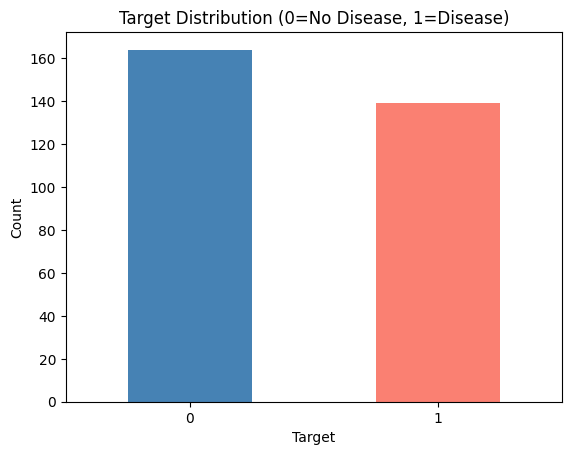

In [4]:
# Target distribution
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Distribution (0=No Disease, 1=Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig(os.path.join(SAVE_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

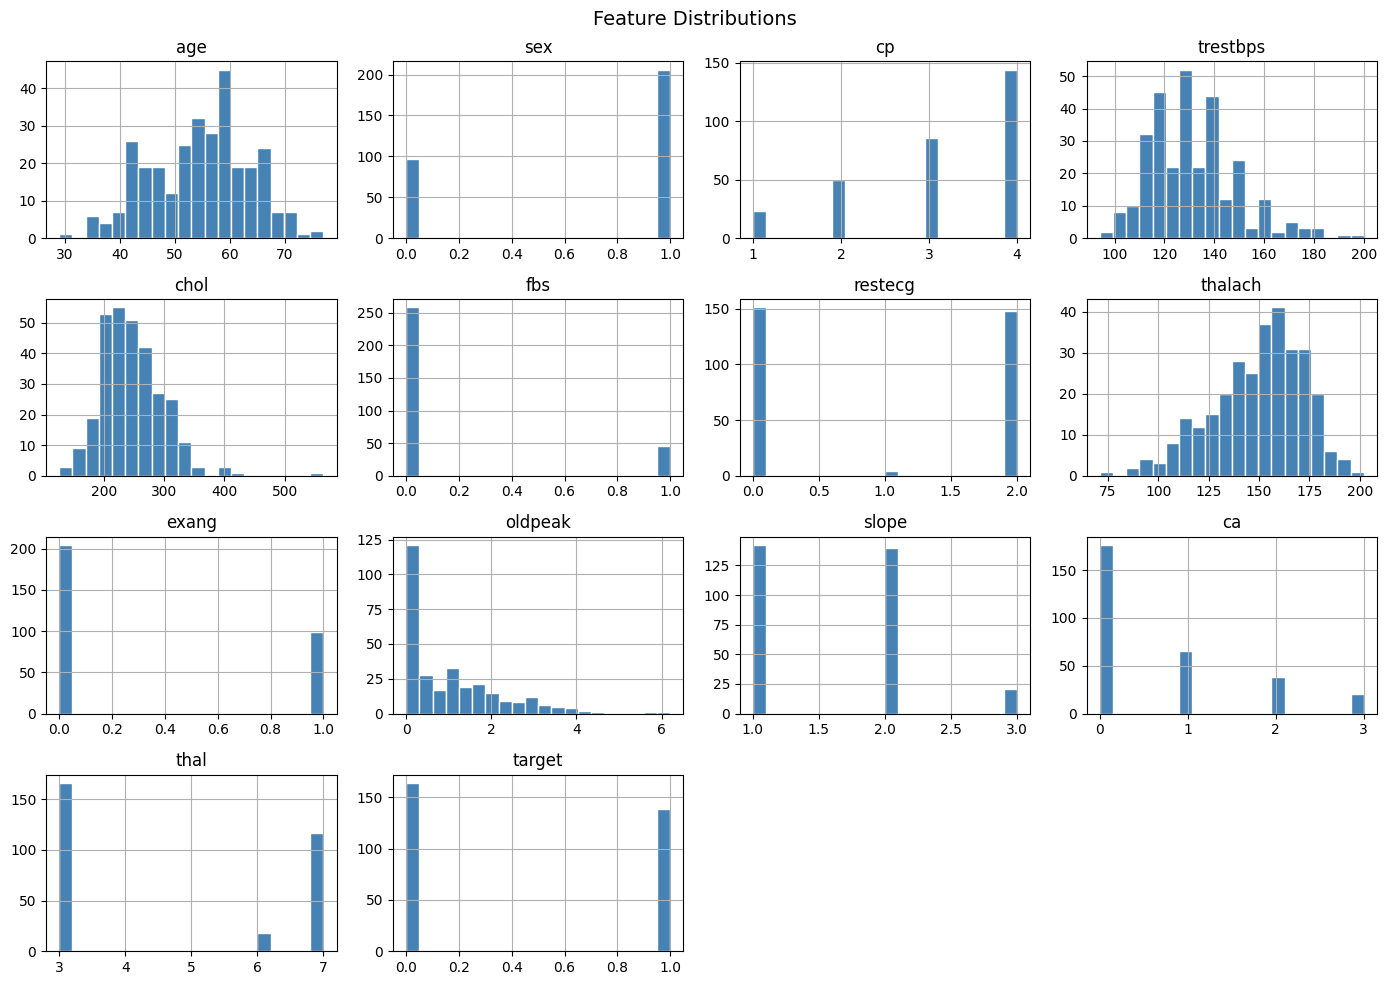

In [5]:
# Feature distributions
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

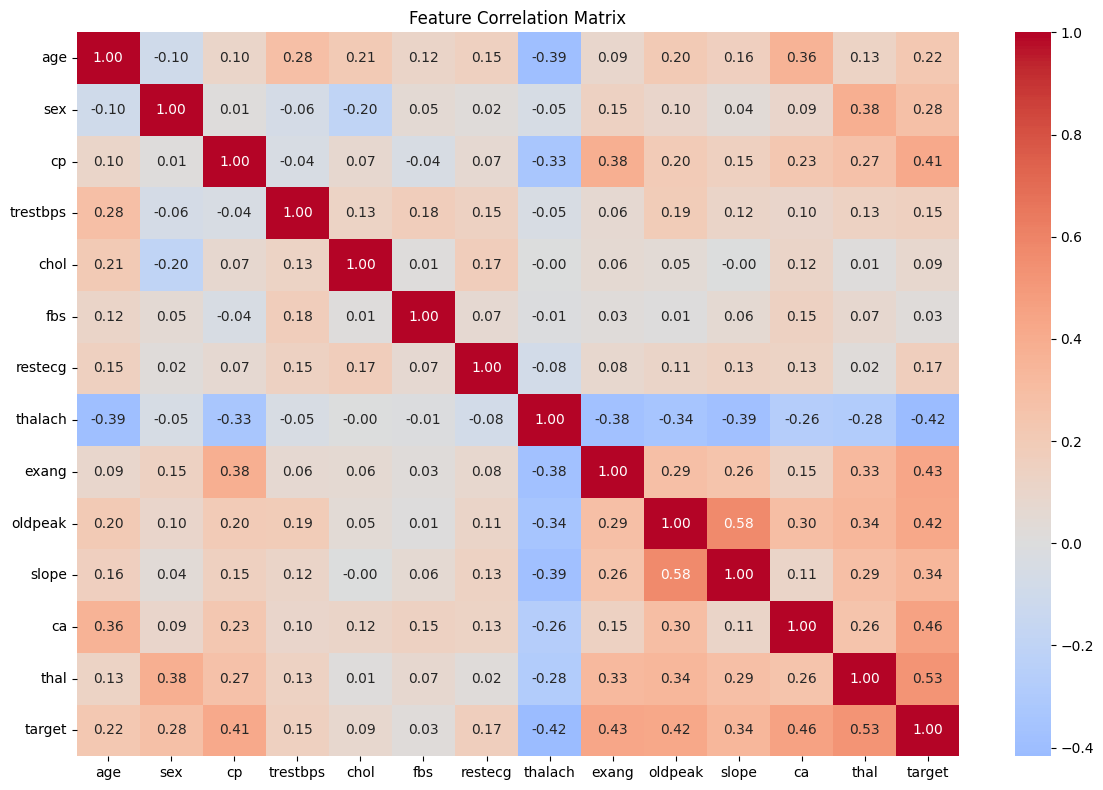

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

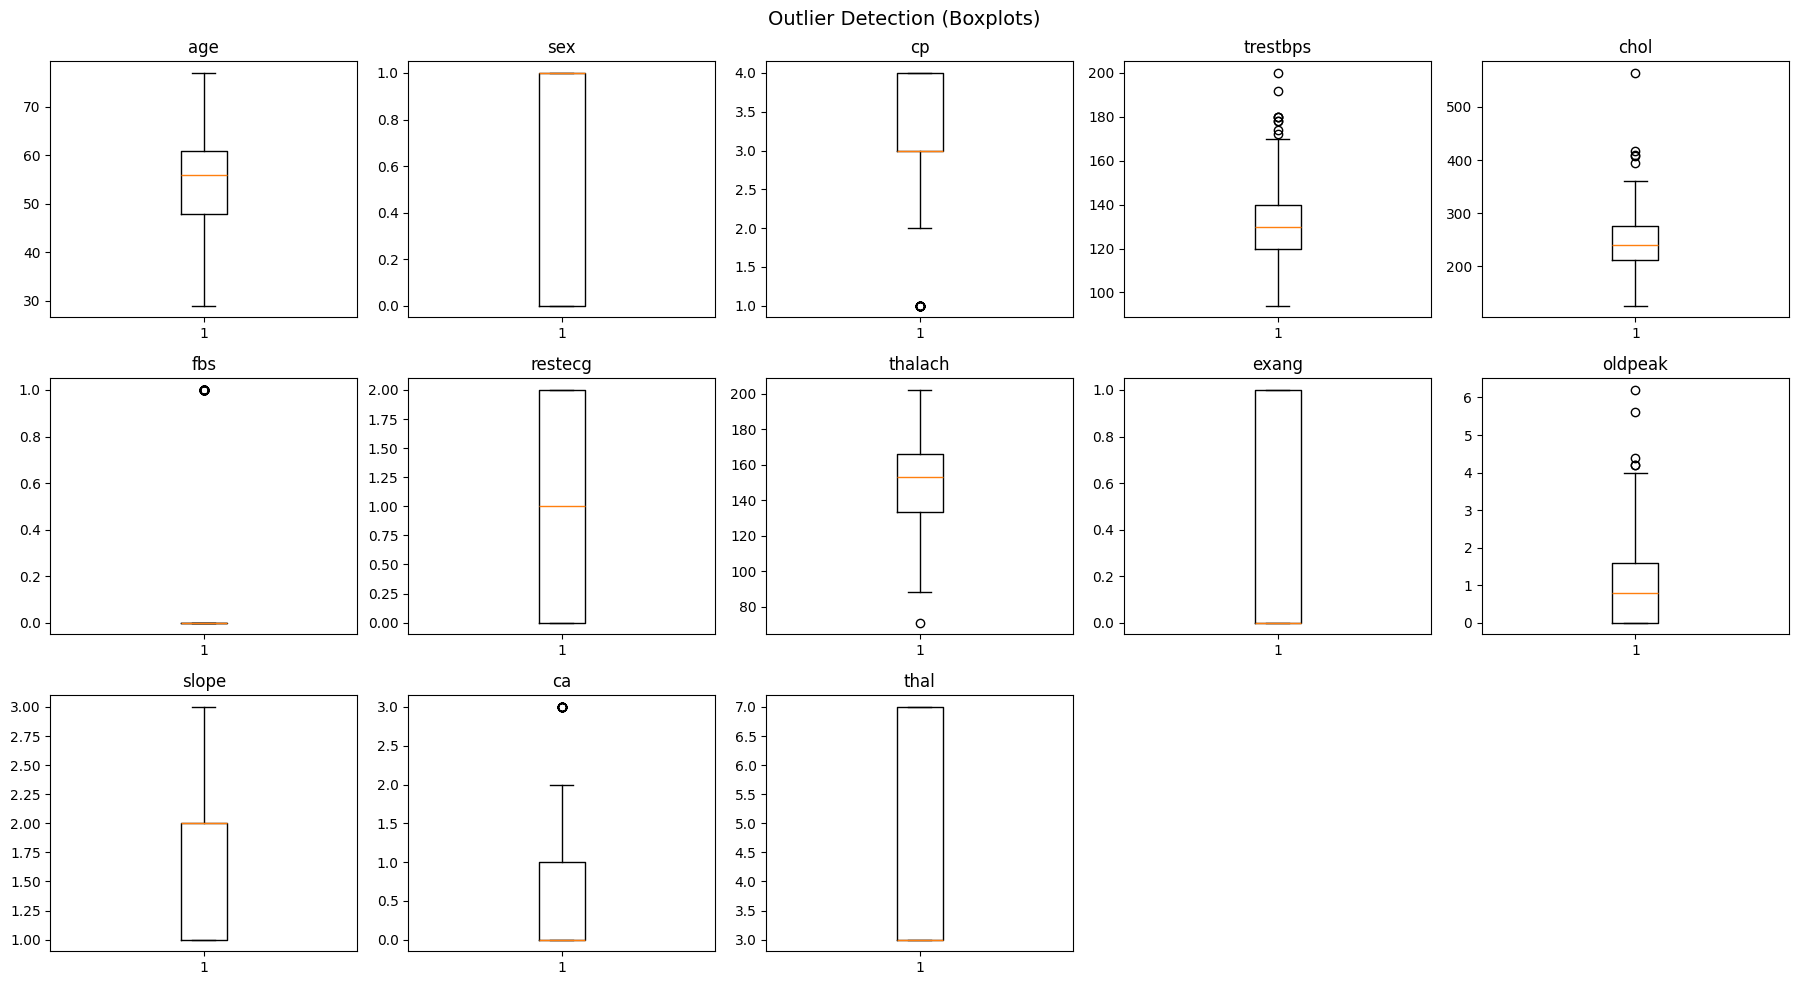

In [7]:
# Outlier detection using boxplots
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Outlier Detection (Boxplots)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'outlier_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

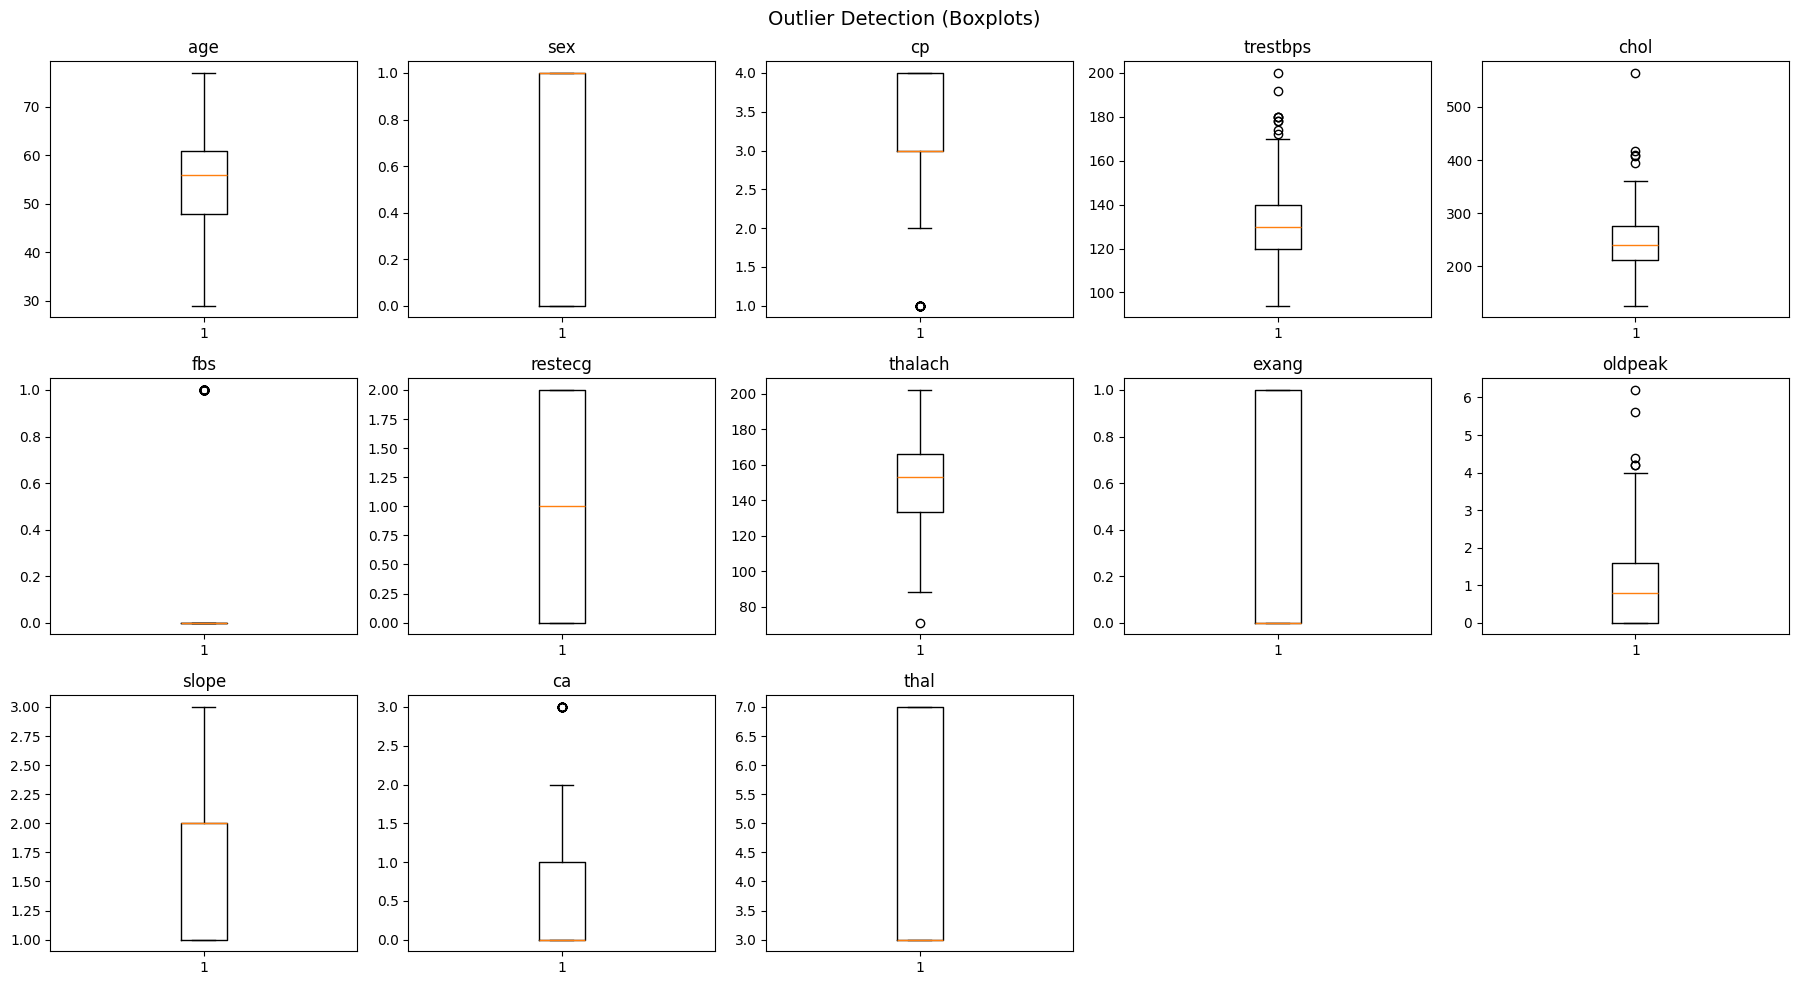

In [8]:
# Outlier detection using boxplots
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Outlier Detection (Boxplots)', fontsize=14)
plt.tight_layout()
plt.show()

## TODO (Rabiya)
After exploring, answer these questions before writing the preprocessor:
1. Which columns have missing values? How will you handle them?
2. Are there any categorical columns that need encoding?
3. Which columns have strong outliers that need treatment?
4. Does the class distribution need balancing (check target counts above)?

## Rabiya's EDA Answers

**1. Missing values?**
`ca` has 4 missing values and `thal` has 2 — total 6 out of 303 rows.
Strategy: fill with **column median** (both are ordinal/numeric, median is robust to outliers and keeps all 303 rows).

**2. Categorical columns needing encoding?**
None. Every column in the UCI Cleveland dataset is already numeric:
- `sex`: 0/1 binary
- `cp`, `restecg`, `slope`, `ca`, `thal`: integer-coded ordinal/categorical
- `fbs`, `exang`: 0/1 binary
No `pd.get_dummies` or `LabelEncoder` needed.

**3. Strong outliers?**
- `chol`: several values >400 mg/dL (clinically possible but extreme)
- `trestbps`: a few values >180 mmHg
- `oldpeak`: right-skewed, values up to 6.2
Strategy: keep all values (they are clinically valid, not data errors). `StandardScaler` reduces their relative magnitude without discarding real cases.

**4. Class balance?**
164 no-disease (54%) vs 139 disease (46%) — roughly balanced.
No resampling (SMOTE / class_weight) needed; the ~8% imbalance is small enough that all four models will train reliably.